In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import joblib
import time

# Load data
X_train = pd.read_csv('../../data/X_train.csv')
X_test = pd.read_csv('../../data/X_test.csv')
y_train = pd.read_csv('../../data/y_train.csv').squeeze()
y_test = pd.read_csv('../../data/y_test.csv').squeeze()

print("✅ Data loaded!")
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Target classes: 0=Low, 1=Mid, 2=High")

✅ Data loaded!
Train: (2283, 18) | Test: (571, 18)
Target classes: 0=Low, 1=Mid, 2=High


 Train All 4 Models

In [ ]:
# Define all 4 models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42)
}

# Train and evaluate all models
results = {}

print("Training models...\n")
for name, model in models.items():
    start = time.time()
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Score
    acc = accuracy_score(y_test, y_pred)
    duration = round(time.time() - start, 2)
    
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': acc,
        'time': duration
    }
    
    print(f"✅ {name}")
    print(f"   Accuracy : {acc*100:.2f}%")
    print(f"   Time     : {duration}s\n")

Training models...

✅ Logistic Regression
   Accuracy : 66.73%
   Time     : 2.45s

✅ Decision Tree
   Accuracy : 64.97%
   Time     : 0.03s

✅ Random Forest
   Accuracy : 64.27%
   Time     : 0.73s

✅ Gradient Boosting
   Accuracy : 67.78%
   Time     : 2.23s



Deep Dive on Best Model

🏆 Best Model: Gradient Boosting
   Accuracy: 67.78%

📊 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Low Salary       0.50      0.04      0.07        52
  Mid Salary       0.65      0.89      0.75       306
 High Salary       0.77      0.54      0.63       213

    accuracy                           0.68       571
   macro avg       0.64      0.49      0.48       571
weighted avg       0.68      0.68      0.64       571



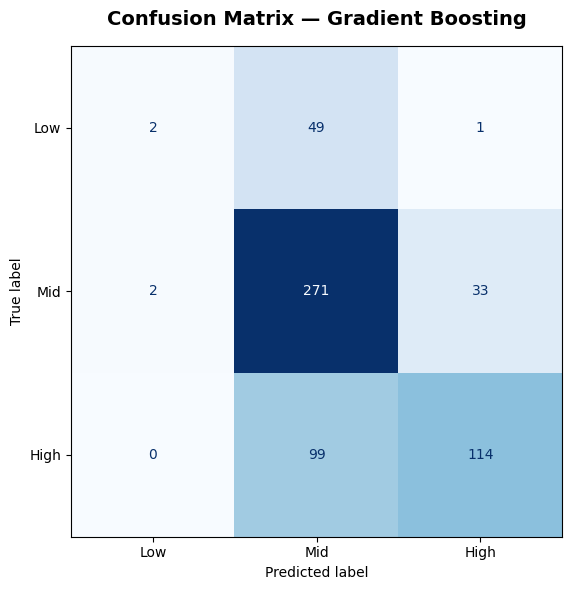

In [5]:
# Get best model
best_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_name]['model']
best_preds = results[best_name]['predictions']

print(f"🏆 Best Model: {best_name}")
print(f"   Accuracy: {results[best_name]['accuracy'] * 100:.2f}%")

# Detailed classification report
print("\n📊 DETAILED CLASSIFICATION REPORT:")
print("=" * 55)
print(classification_report(
    y_test, best_preds,
    target_names=['Low Salary', 
                  'Mid Salary', 
                  'High Salary']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Mid', 'High'])
disp.plot(ax=ax, colorbar=False,
          cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../../data/day7_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

Feature Importance


🔍 TOP 10 MOST IMPORTANT FEATURES:
               Feature  Importance
           exp_encoded    0.197831
          skill_python    0.152884
         title_encoded    0.149064
skill_machine_learning    0.100449
                 views    0.084950
            apply_rate    0.074124
               applies    0.053382
             skill_aws    0.036265
           skill_spark    0.034617
           is_fulltime    0.027066


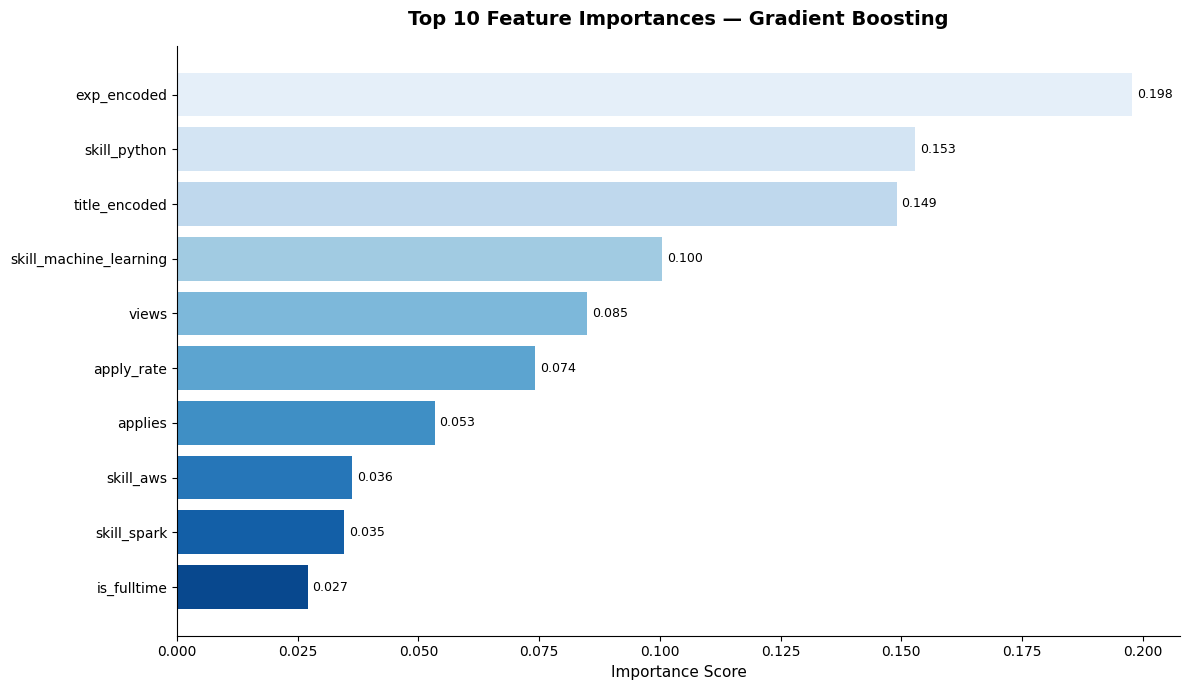

In [7]:
# Feature importance (works for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\n🔍 TOP 10 MOST IMPORTANT FEATURES:")
    print(importance.head(10).to_string(index=False))

    # Plot
    fig, ax = plt.subplots(figsize=(12, 7))
    top10 = importance.head(10)
    ax.barh(top10['Feature'][::-1],
            top10['Importance'][::-1],
            color=sns.color_palette("Blues_r", 10))
    ax.set_title(f'Top 10 Feature Importances — {best_name}',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Importance Score', fontsize=11)

    for i, val in enumerate(top10['Importance'][::-1]):
        ax.text(val + 0.001, i,
                f'{val:.3f}', va='center', fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('../../data/day7_feature_importance.png',
                dpi=150, bbox_inches='tight')
    plt.show()

Save Best Model

In [9]:
import os
import json
import joblib

# Create models folder if not exists
os.makedirs('../../models', exist_ok=True)

# Save best model
joblib.dump(best_model, '../../models/best_model.pkl')

# Save feature names
joblib.dump(X_train.columns.tolist(),
            '../../models/feature_names.pkl')

# Save label mapping
label_map = {
    0: 'Low (<$60k)',
    1: 'Mid ($60k-$120k)',
    2: 'High (>$120k)'
}

with open('../../models/label_map.json', 'w') as f:
    json.dump(label_map, f)

print("✅ Model saved successfully!")
print(f"   Model: {best_name}")
print(f"   File: models/best_model.pkl")
print(f"   Accuracy: {results[best_name]['accuracy'] * 100:.2f}%")

print("\n🎯 Ready for Day 8 — Model Explainability!")

✅ Model saved successfully!
   Model: Gradient Boosting
   File: models/best_model.pkl
   Accuracy: 67.78%

🎯 Ready for Day 8 — Model Explainability!


 Real World Test

In [10]:
# Test your model with a real example!
import numpy as np

# Create a sample fresher profile
print("🧪 REAL WORLD PREDICTION TEST")
print("=" * 45)

sample_profiles = [
    {
        'name': 'Fresher — Python + ML skills',
        'features': [0, 1, 1, 1, 1, 100, 10, 0.1,
                     1, 1, 1, 0, 0, 1, 0, 0, 0, 1]
    },
    {
        'name': 'Senior — All skills, experienced',
        'features': [1, 1, 3, 3, 1, 500, 50, 0.1,
                     1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
    },
    {
        'name': 'Entry level — Excel + SQL only',
        'features': [0, 1, 1, 0, 1, 50, 5, 0.1,
                     0, 1, 1, 0, 0, 0, 0, 0, 0, 0]
    }
]

for profile in sample_profiles:
    features = np.array(profile['features']).reshape(1, -1)
    pred = best_model.predict(features)[0]
    prob = best_model.predict_proba(features)[0]
    
    print(f"\nProfile: {profile['name']}")
    print(f"Predicted Salary: {label_map[pred]}")
    print(f"Confidence: {max(prob)*100:.1f}%")
    print(f"  Low:  {prob[0]*100:.1f}%")
    print(f"  Mid:  {prob[1]*100:.1f}%")
    print(f"  High: {prob[2]*100:.1f}%")

🧪 REAL WORLD PREDICTION TEST

Profile: Fresher — Python + ML skills
Predicted Salary: Mid ($60k-$120k)
Confidence: 80.0%
  Low:  0.2%
  Mid:  80.0%
  High: 19.8%

Profile: Senior — All skills, experienced
Predicted Salary: High (>$120k)
Confidence: 88.4%
  Low:  0.3%
  Mid:  11.3%
  High: 88.4%

Profile: Entry level — Excel + SQL only
Predicted Salary: Mid ($60k-$120k)
Confidence: 79.1%
  Low:  2.1%
  Mid:  79.1%
  High: 18.8%
